In [32]:
import numpy as np
import plotly.express as px
from sklearn.datasets import make_blobs

In [160]:
X,y= make_blobs(n_samples=300, n_features=4, centers=5, random_state=42)

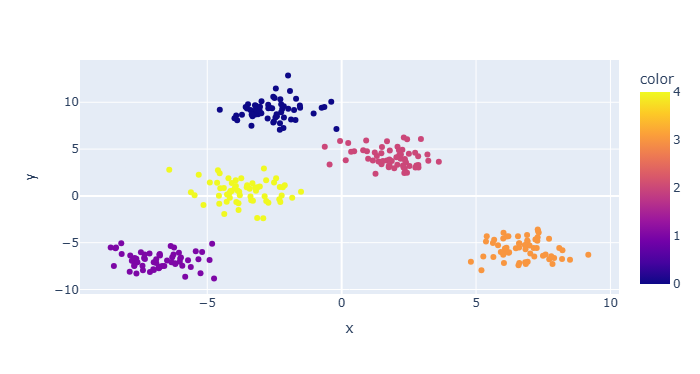

In [161]:
px.scatter(x=X[:,0],y=X[:,1],color=y)

In [162]:
import random
class kmeansCluster:
    def __init__(self,k,plot=False):
        self.k=k
        self.plot=plot
        self.centroids=[[random.random(),random.random()] for i in range(k)]

    def train(self,X):
        self.clustersF=[]
        count=1
        while True:
            clusters=[[] for i in range(self.k)]
            for pt in X:
                min_dist=float('inf')
                for i in range(self.k):
                    d=self.cal_eu_dist(self.centroids[i],pt)
                    if d<min_dist:
                        min_dist=d
                        centr_no=i
                clusters[centr_no]+=[pt]
            new_centroids = []
            for cluster in clusters:
                if len(cluster) == 0:
                    # No points in this cluster → re-initialize this centroid randomly
                    new_centroids.append([random.random(), random.random()])
                else:
                    mean_pt = np.mean(cluster, axis=0).tolist()
                    new_centroids.append(mean_pt)
            if new_centroids==self.centroids:
                 self.clustersF=clusters
                 return
                
            if self.plot:
                clsNo=[]
                for pt in X:
                    pt=list(pt)
                    for i in range(len(clusters)):
                        if pt in list([list (k) for k in clusters[i]]):
                            clsNo.append(i)
                            break
                            
                px.scatter(x=X[:,0],y=X[:,1],color=clsNo,title=f"Iteration {count}").show()
                count+=1
            self.centroids=new_centroids
            
    def cal_eu_dist(self,pt1,pt2):
            dist=0
            for i in range(len(pt1)):
                dist+=(pt1[i]-pt2[i])**2
            return dist

    def calc_wlss(self,list_of_k,X):
        ans=[]
        for k in list_of_k:
            obj=kmeansCluster(k)
            obj.train(X)
            centroids=obj.centroids
            clusters=obj.clustersF
            dist=0
            for i in range(len(centroids)):
                dist+=sum([obj.cal_eu_dist(centroids[i],p) for p in clusters[i]])
            ans.append(dist)
        return ans

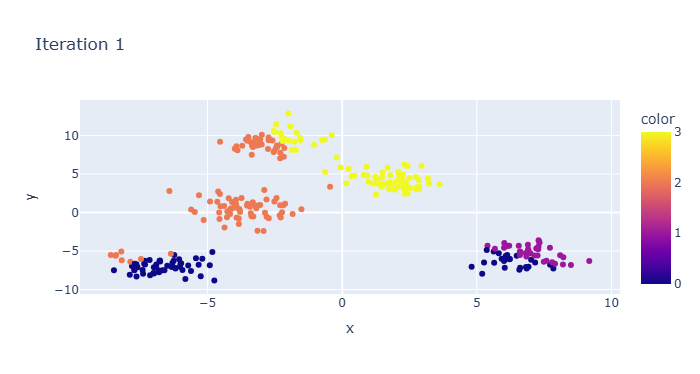

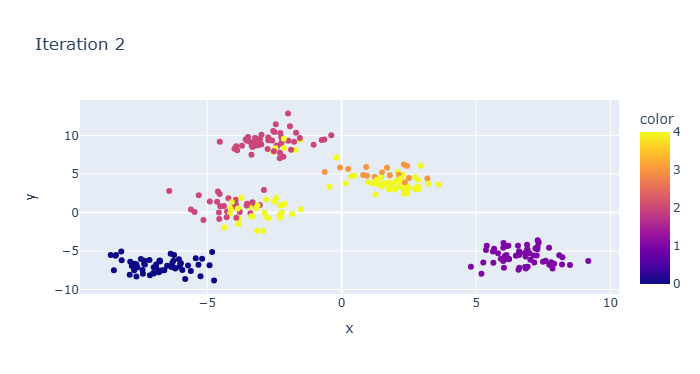

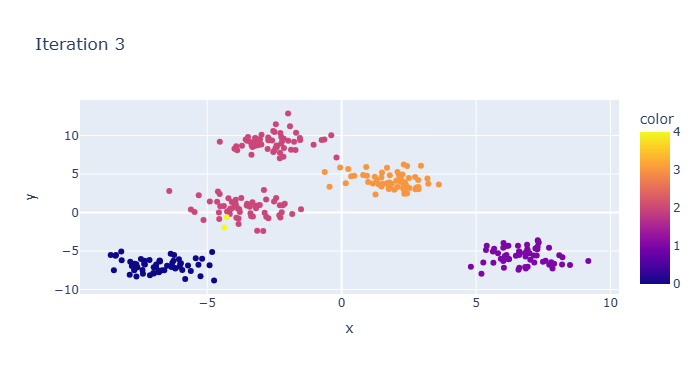

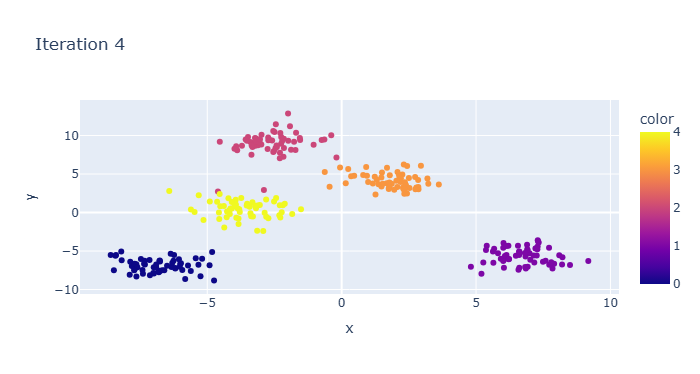

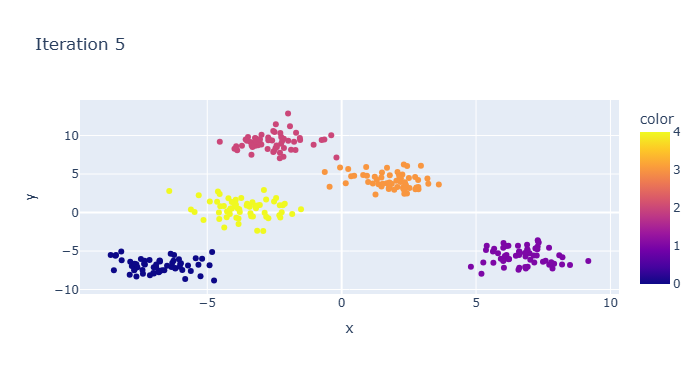

In [165]:
kmeans=kmeansCluster(5,True)
kmeans.train(X)

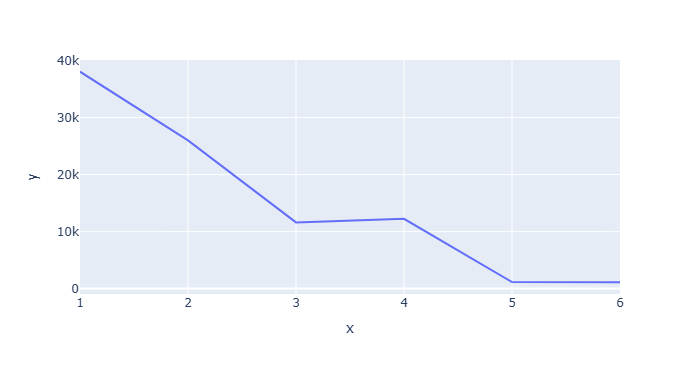

In [166]:
#elbow curve

wlss=kmeans.calc_wlss([1,2,3,4,5,6],X)
px.line(x=[1,2,3,4,5,6],y=wlss)